**Daniel Yu & Jordan Wang**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 2: Predictive Coding

#### Week 2: Predictive coding: classification and image generation

With the Dense PCN built, let's analyze its classification accuracy on MNIST and CIFAR-10 and explore its generative image capabilities. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 3: Dense PCN and MNIST

Now you are ready to train your Dense PCN on MNIST!

In addition to optimizing the classification accuracy, you will:
1. visualize the "ideal" digit that each output neuron of a trained net "expects to see".
2. leverage this generative capability of PCNs to "fill in" blanked out parts of test samples.

In [17]:
from image_datasets import get_dataset, train_val_split
from dense_pcn import DensePCN

### 3a. Train and evaluate classification accuracy on MNIST

In the cell below, train a Dense PCN with 1 hidden layer on *centered* preprocessed MNIST samples with the default train/val/test split.

Your goal is to play with the following hyperparameters to obtain **≥75% accuracy on the test set**:
- number of epochs
- batch size
- number of units

Fix your learning rate to `1e-4` and use the default number of train/test feedback iterations.

Be sure to print out your test accuracy.


**Notes:**
- If your training is working properly, you should see your training loss consistently decline.
- You should not need to train for many epochs to hit the accuracy target. 
- I suggest setting a random seed so that similar to the test code your results do not fluctuate based on differences in initial random weights between runs.

In [6]:
tf.random.set_seed(0)
np.random.seed(0)

x_train_full, y_train_full, x_test, y_test = get_dataset('mnist', norm_method='center')

x_train, y_train, x_val, y_val = train_val_split(x_train_full, y_train_full, prop_val=0.1)

print(f'Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}')

Dataset: mnist
x_train: (60000, 784) <dtype: 'float32'>
y_train: (60000,) <dtype: 'uint8'>
x_test:  (10000, 784) <dtype: 'float32'>
y_test:  (10000,) <dtype: 'uint8'>
Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)


---------------------------------------------------------------------------
OutputLayer (10 units). Output shape: [1, 10]
PredLayer_0 (512 units). Output shape: [1, 512]
InputLayer (784 units). Output shape: [1, 784]
---------------------------------------------------------------------------
Epoch 0/4, Training loss 17.441429, Val loss 16.909880, Val acc 0.7898
Epoch 0 took: 44.6 secs
Epoch 1/4, Training loss 8.679012, Val loss 12.257739, Val acc 0.8248
Epoch 1 took: 45.7 secs
Epoch 2/4, Training loss 6.106722, Val loss 12.172256, Val acc 0.8335
Epoch 2 took: 46.5 secs
Epoch 3/4, Training loss 4.839049, Val loss 11.984758, Val acc 0.8347
Epoch 3 took: 47.0 secs
Epoch 4/4, Training loss 4.055690, Val loss 12.513502, Val acc 0.8347
Epoch 4 took: 44.6 secs
Finished training after 5 epochs!


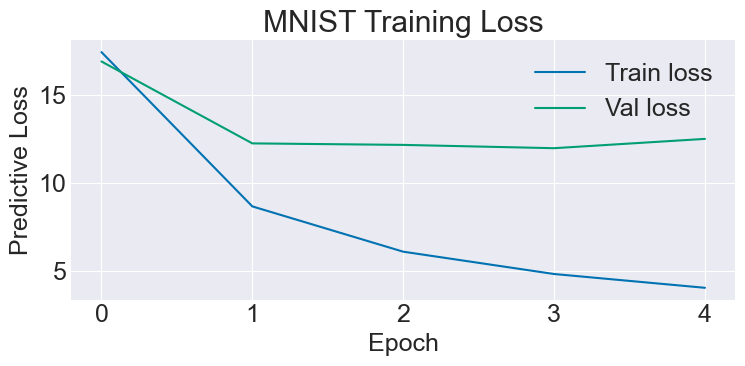


Test accuracy (10 steps): 0.8067
Test loss: 12.5448


In [7]:

net = DensePCN(
    input_feats_shape=(784,),
    C=10,
    hidden_units=(512,),
    wt_scale=1e-2,
    gamma_lr=0.1,
    train_num_steps=20,
    test_num_steps=10
)

net.compile(
    loss='predictive',
    lr=1e-4
)

train_losses, val_losses, val_accs, _ = net.fit(
    x_train, y_train,
    x_val, y_val,
    max_epochs=5,
    batch_size=128,
    verbose=True
)

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Predictive Loss')
plt.title('MNIST Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

test_acc, test_loss = net.evaluate(x_test, y_test)
print(f'\nTest accuracy (10 steps): {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

### 3b. Hyperparameter tuning: test steps

With the same hyperparameters that you used in the previous subtask, run inference on your Dense PCN to compute the test accuracy with the following number of test steps: `1, 10, 20, 30, ..., 100`.

Make a plot showing the MNIST test accuracy in each case.

Steps=  1  ->  Test acc = 0.7343
Steps= 10  ->  Test acc = 0.8067
Steps= 20  ->  Test acc = 0.7796
Steps= 30  ->  Test acc = 0.7690
Steps= 40  ->  Test acc = 0.7710
Steps= 50  ->  Test acc = 0.7751
Steps= 60  ->  Test acc = 0.7793
Steps= 70  ->  Test acc = 0.7841
Steps= 80  ->  Test acc = 0.7874
Steps= 90  ->  Test acc = 0.7908
Steps=100  ->  Test acc = 0.7944


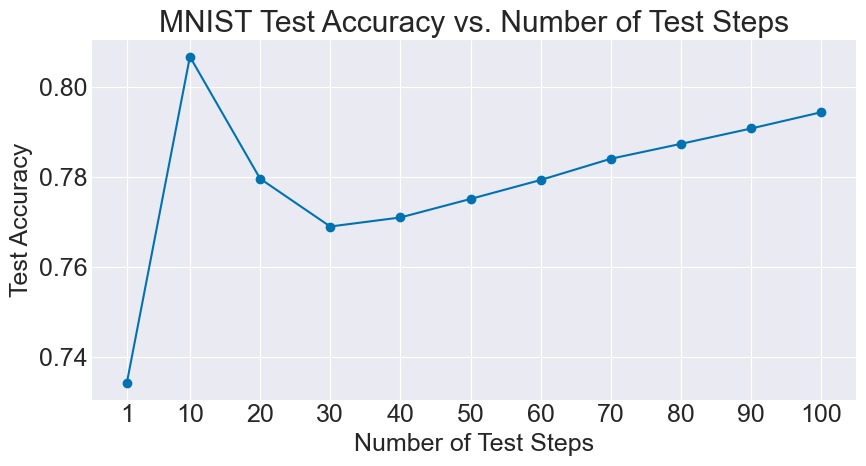


Best accuracy: 0.8067 at 10 test steps


In [8]:
step_counts = [1] + list(range(10, 101, 10))
accuracies = []

for steps in step_counts:
    net.set_test_num_steps(steps)
    acc, _ = net.evaluate(x_test, y_test)
    accuracies.append(acc)
    print(f'Steps={steps:3d}  ->  Test acc = {acc:.4f}')

# Plot
plt.figure(figsize=(9, 5))
plt.plot(step_counts, accuracies, marker='o')
plt.xlabel('Number of Test Steps')
plt.ylabel('Test Accuracy')
plt.title('MNIST Test Accuracy vs. Number of Test Steps')
plt.xticks(step_counts)
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(accuracies))
print(f'\nBest accuracy: {accuracies[best_idx]:.4f} at {step_counts[best_idx]} test steps')

### 3c. Questions

**Question 2:** (a) What number of test steps produced the optimal test accuracy for you? (b) What was the best test accuracy that you achieved and how does that compare to the baseline that you found in the previous subtask?

**Question 3:** Compared to the baseline number of steps, why would the larger (or smaller) number of steps lead to improved accuracy in the PCN?

**Answer 2:**

(a) The optimal test accuracy was achieved at **10 test steps** (80.76%), which is also the default baseline from 3a.

(b) The best test accuracy was **80.76%** at 10 steps. Accuracy then dips at 20–30 steps before gradually recovering, reaching ~79.4% at 100 steps — but never surpassing the 10-step peak within this sweep.

**Answer 3:**

At 10 steps the states sit near a sweet spot: the forward pass initialises them well and a small number of feedback iterations sharpens the representation without over-correcting. Beyond 10 steps the fixed-step-size (γ) gradient-descent-like updates initially *overshoot* the minimum-prediction-error fixed point, causing the accuracy to dip at 20–30 steps. As iterations increase further the dynamics gradually damp back toward convergence, so accuracy climbs again. But the oscillation means it plateaus below the 10-step peak within the 100-step window. This non-monotone behaviour is characteristic of gradient descent with a fixed learning rate applied to a system that is not strongly convex: the optimal stopping point depends on γ and the network’s weight scale.

### 3d. Expected class images

Follow the inline instructions to finish the implementation of the `dream_input` method in the `DensePCN` class. Afterwards, run the code provided below to visualize the expected input for each output neuron of your PCN!

*You should see a very cool ~30 sec animation when running the cell below.*

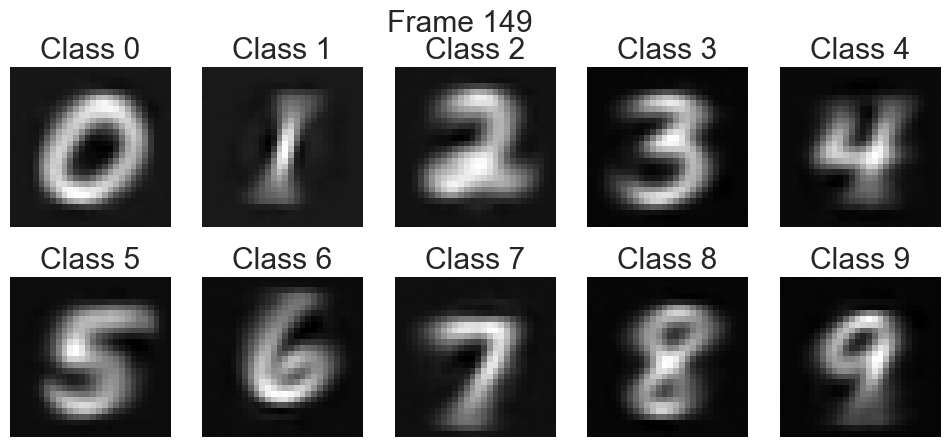

In [9]:
# Keep me
class_names = tf.range(10)
net.dream_input(class_names)

### 3e. Questions

**Question 4:** Describe what you see in the animation and interpret what it means (i.e. why do you see what you see in each figure panel in the order in which you see it).

**Answer 4:**

At the start of the animation (frame 0) all 10 panels show uniform grey/noisy textures, which is because the input-layer state has been initialised to small random Gaussian noise with no digit structure whatsoever.

Over the course of the subsequent frames the images gradually sharpen into recognisable digit shapes: panel 0 resolves into something resembling a "0", panel 1 into a "1", and so on. By the end of the animation each panel displays a blurry but interpretable prototype of the corresponding digit class.

This happens because each output neuron is clamped to 1 (its "on" state) while the input-layer state is left free to evolve. At every step the feedback signal from the clamped output neuron propagates back through the hidden layer and drives the input-layer state towards whatever pixel pattern would *minimise the prediction error* under that neuron's learned generative model — i.e. the average digit that the neuron has learned to expect as input when it is active. The animation therefore visualises the PCN "dreaming" the prototypical image for each class purely from top-down, generative feedback, with no bottom-up image data present.

### 3f. Filling in occluded parts of images

This subtask focuses on a neat application of the generative capabilities of PCNs — filling in or completing parts of test images that are *missing* (i.e. blanked out). 

#### (i) Visualizing occluded MNIST images

Run the cell below to generate versions of test set images in which the top half of pixels is blanked (**masked**) out.

*For the first few MNIST test set images, you should see the original image (top), occluded image (middle) and the occlusion mask used to generate the occluded image (bottom). In this plotting convention, parts of the mask that zero out corresponding parts of each image sample are black (0s) and parts that preserve the image data are white (1s).*

In [10]:
from image_datasets import occlude_images

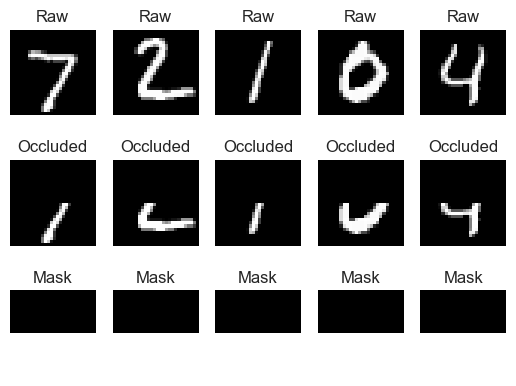

In [11]:
x_test_occ, masks = occlude_images(x_test, region='top')

items = [x_test, x_test_occ, masks]
labels = ['Raw', 'Occluded', 'Mask']

num_samples = 5
fig, axes = plt.subplots(3, num_samples)
for i in range(num_samples):
    for j in range(3):
        axes[j, i].imshow(tf.reshape(items[j][i], (28, 28)), cmap='gray')
        axes[j, i].set_title(labels[j], fontsize=12)
        axes[j, i].grid(False)
        axes[j, i].set_xticks([])
        axes[j, i].set_yticks([])

plt.show()

#### (ii) Add support for dreaming in masked parts of images

We will use your PCN's generative dreaming capability to "fill in" the occluded parts of the image based on the available information and the net's expectation for what should appear in the occluded image regions. For this to work, we need to slightly modify how your `InputPCNLayer` modifies its state: we ONLY want to have the net dream in MASKED parts of the image (non-occluded raw pixels should remain untouched as the state is updated).

In `InputPCNLayer` make the following small updates:
1. Implement `set_mask` to create an instance variable to store the masks for each test set mini-batch.
2. Modify `update_state` to use the occlusion mask to zero out the *top-down prediction error* in places where the input images were NOT MASKED by the occlusion mask (i.e. in places where there is actual useful image data). If there is no mask, modify the state like usual.

#### (iii) Finish method to fill in masked regions of image and animate the process

Follow the inline instructions to finish the implementation of the `complete_input` method in the `DensePCN` class, which will fill in the occluded parts of MNIST images.

Run the following code to animate the filling in process. *You should see a ~30 sec animation.*

**Note:** Replace `net` with your trained net's name.


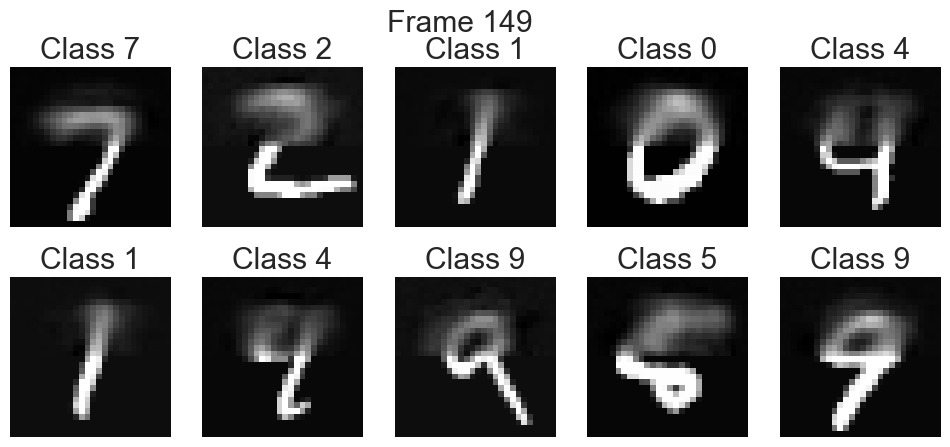

In [12]:
min_ind = 0
max_ind = 10
net.complete_input(x_test_occ[min_ind:max_ind],
                   masks[min_ind:max_ind],
                   y_test[min_ind:max_ind])

### 3g. Questions

**Question 5:**

(a) How closely do the filled in images resemble the original images?

(b) How sensible/plausible are the filled in content by the network?

**Answer 5:**

(a) The filled-in images are *broadly* similar to the originals but rarely a pixel-perfect match. The bottom halves of the digits (which are preserved by the mask and serve as the bottom-up evidence) appear unchanged. The reconstructed top halves tend to capture the correct gross structure — rounded tops for "0" or "8", a horizontal crossbar for "4" or "7" — but the fine-grained details (exact stroke thickness, curvature, position) differ from the original because the network is generating the prototypical top half for that class rather than recovering the specific sample.

(b) The completed content is highly plausible. Even when the reconstructed top differs from the ground-truth, the result is almost always a recognisable, valid-looking digit of the correct class. This makes sense: the output layer is clamped to the true label, so the top-down signal encodes exactly which digit class is present, and the network hallucinates a top half that is consistent with that class and with the visible bottom-half pixels. The reconstruction therefore illustrates the PCN's learned generative model rather than a memory of the specific test sample.

## Task 4: Dense PCN and CIFAR-10

This task focuses on evaluating the classification accuracy of your dense PCN on CIFAR-10. You will also visualize the expected images corresponding to each output neuron.

### 4a. Train and evaluate classification accuracy on CIFAR-10

In the cell below, train a Dense PCN with 1 hidden layer on *centered* preprocessed CIFAR-10 samples with the default train/val/test split.

Use default hyperparameters, except for the following:
- `10` epochs.
- Batch size of `256`.
- Learning rate of `1e-4`.

Print out the accuracy that you obtain on the test set. If everything is working as expected, you should be able to obtain **test accuracy ≥ 25%**.

In [13]:
tf.random.set_seed(0)
np.random.seed(0)

x_train_full, y_train_full, x_test, y_test = get_dataset('cifar10', norm_method='center')

x_train, y_train, x_val, y_val = train_val_split(
    x_train_full, y_train_full, prop_val=0.1
)

print(f'Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}')

/Users/jordanwang/Desktop/CS443/.venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Dataset: cifar10
x_train: (50000, 3072) <dtype: 'float32'>
y_train: (50000,) <dtype: 'uint8'>
x_test:  (10000, 3072) <dtype: 'float32'>
y_test:  (10000,) <dtype: 'uint8'>
Train: (45000, 3072), Val: (5000, 3072), Test: (10000, 3072)


---------------------------------------------------------------------------
OutputLayer (10 units). Output shape: [1, 10]
PredLayer_0 (256 units). Output shape: [1, 256]
InputLayer (3072 units). Output shape: [1, 3072]
---------------------------------------------------------------------------
Epoch 0/9 | Train loss: 62.409907 | Val loss: 111.274055 | Val acc: 0.2175
Epoch 0/9 | Train loss: 62.409907 | Val loss: 111.274055 | Val acc: 0.2175
Epoch 1/9 | Train loss: 36.940376 | Val loss: 120.644104 | Val acc: 0.2609
Epoch 1/9 | Train loss: 36.940376 | Val loss: 120.644104 | Val acc: 0.2609
Epoch 2/9 | Train loss: 29.312193 | Val loss: 44.330032 | Val acc: 0.2689
Epoch 2/9 | Train loss: 29.312193 | Val loss: 44.330032 | Val acc: 0.2689
Epoch 3/9 | Train loss: 25.131455 | Val loss: 33.501213 | Val acc: 0.2788
Epoch 3/9 | Train loss: 25.131455 | Val loss: 33.501213 | Val acc: 0.2788
Epoch 4/9 | Train loss: 22.263298 | Val loss: 32.798958 | Val acc: 0.2833
Epoch 4/9 | Train loss: 22.263298 |

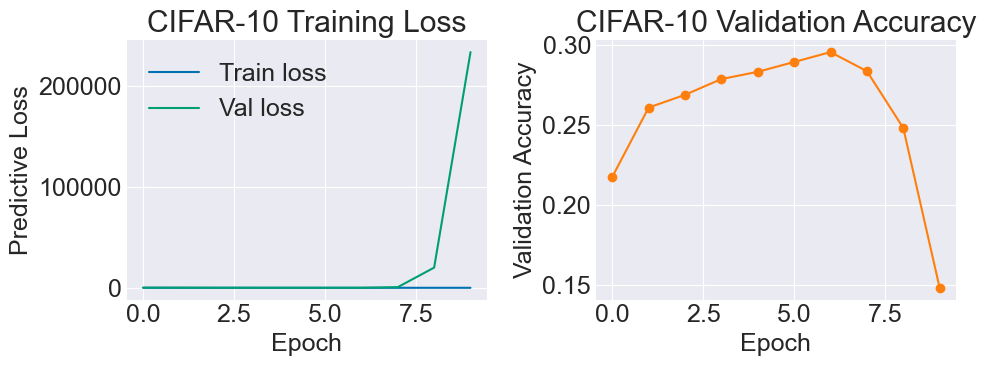

Best val acc: 0.2956 at epoch 6 | Test acc: 0.2987 | Test loss: 42.2745


In [21]:
net = DensePCN(
    input_feats_shape=(3072,),
    C=10,
    hidden_units=(256,),
    wt_scale=1e-2,
    gamma_lr=0.1,
    train_num_steps=20,
    test_num_steps=10,
 )

net.compile(loss='predictive', lr=1e-4)

max_epochs = 10
batch_size = 256
rng = np.random.RandomState(0)
N = len(x_train)
num_batches = N // batch_size + int(N % batch_size != 0)

train_losses, val_losses, val_accs = [], [], []
best_val_acc = -np.inf
best_epoch = -1
best_params = None

for epoch in range(max_epochs):
    epoch_batch_losses = []

    for _ in range(num_batches):
        idx = tf.constant(rng.randint(0, N, size=batch_size))
        x_batch = tf.gather(x_train, idx)
        y_batch = tf.gather(y_train, idx)
        loss = net.train_step(x_batch, y_batch)
        epoch_batch_losses.append(float(loss.numpy()))

    train_loss = float(np.mean(epoch_batch_losses))
    val_acc, val_loss = net.evaluate(x_val, y_val, batch_sz=batch_size)
    val_acc = float(val_acc.numpy())
    val_loss = float(val_loss.numpy())

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f'Epoch {epoch}/{max_epochs-1} | '
        f'Train loss: {train_loss:.6f} | '
        f'Val loss: {val_loss:.6f} | '
        f'Val acc: {val_acc:.4f}'
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_params = [p.numpy().copy() for p in net.get_all_params()]

# Evaluate using best validation checkpoint
for p, p_best in zip(net.get_all_params(), best_params):
    p.assign(p_best)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Predictive Loss')
plt.title('CIFAR-10 Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accs, marker='o', color='tab:orange')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('CIFAR-10 Validation Accuracy')

plt.tight_layout()
plt.show()

test_acc, test_loss = net.evaluate(x_test, y_test, batch_sz=256)
print(
    f'Best val acc: {best_val_acc:.4f} at epoch {best_epoch} | '
    f'Test acc: {float(test_acc.numpy()):.4f} | '
    f'Test loss: {float(test_loss.numpy()):.4f}'
)

### 4b. Visualize expected inputs for each output neuron

Running the following code should show an animation of the expected input according to each output neuron of your trained PCN.

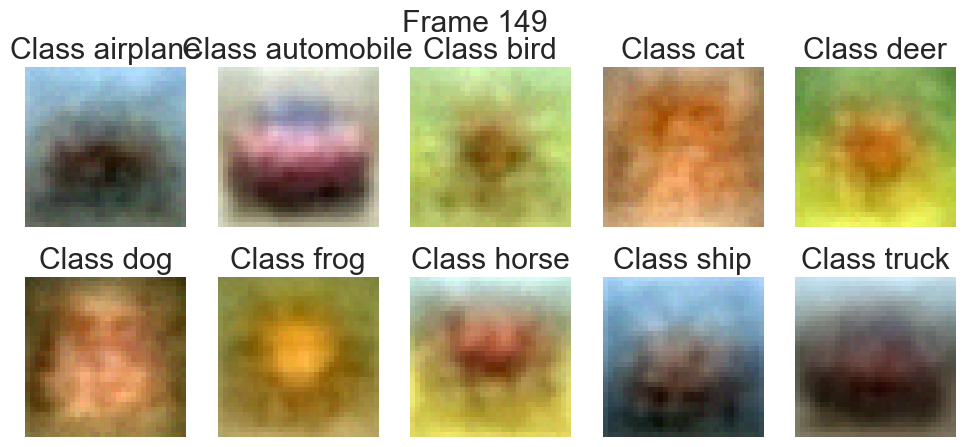

In [15]:
cifar_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
net.dream_input(cifar_class_names, image_dims=(32, 32, 3))

### 4c. Questions

**Question 6:** Why are the expected inputs for each class blurrier than those that you generated for MNIST?

**Question 7:** Why might the blurriness of expected images of each class hinder the potential for feedback in the PCN to raise the classification accuracy?

**Answer 6:**

The CIFAR-10 dreams are blurrier mainly because each class is way more variable than in MNIST. More specifically, a dog image can have different poses, colors, backgrounds, scales, and lighting, while MNIST digits are centered, grayscale, and structurally much more consistent. So when the PCN dreams an input for one CIFAR class, it tends to average over many possible appearances, which smooths edges and fine detail.

Also, CIFAR is only 32×32 and RGB, so the network has to represent much richer variation in a small image. The result is more of a soft class prototype than a crisp, single-template image.

**Answer 7:**

Feedback helps most when top-down predictions are sharp and class-specific. If the expected class image is blurry, the top-down signal is less distinctive, so different classes can look partially compatible with the same vague pattern.

In turn, this weakens the corrective effect of iterative inference. Thus, instead of strongly pulling the current state toward the right class basin, the feedback provides a softer constraint and leaves more ambiguity. In practice, that limits how much extra test-step refinement can improve accuracy on CIFAR compared with MNIST.